In [1]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

import sklearn
import inspect


/opt/anaconda3/envs/PyG_sklearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data and setup Graph dataset

In [2]:
tracker_name = 'Recoil' # Either 'Tagger' or 'Recoil'
use_Edep = False        # Whether to use energy deposition as a external effect in the Interaction Network

in_dir = '/Users/mghrear/data/LDMX_GNN/ldmx-det-v14-8gev_no_filter_2/processed/train/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)



In [3]:
# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo_signal, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SignalID'] = df['SignalID']
df_graph['TruthP'] = df['TruthP']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']

/Users/mghrear/Lab/LDMX/GNN-tracking-ldmx/GNNTrackingTools.py:70: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


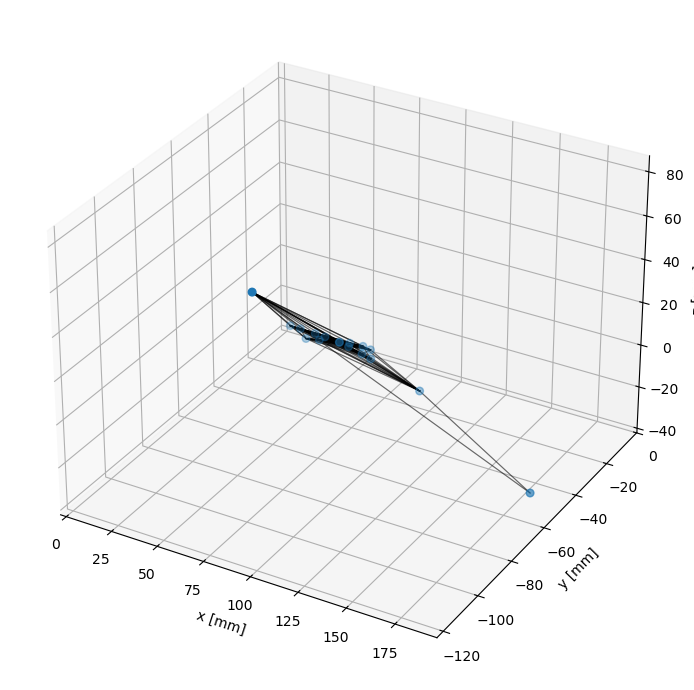

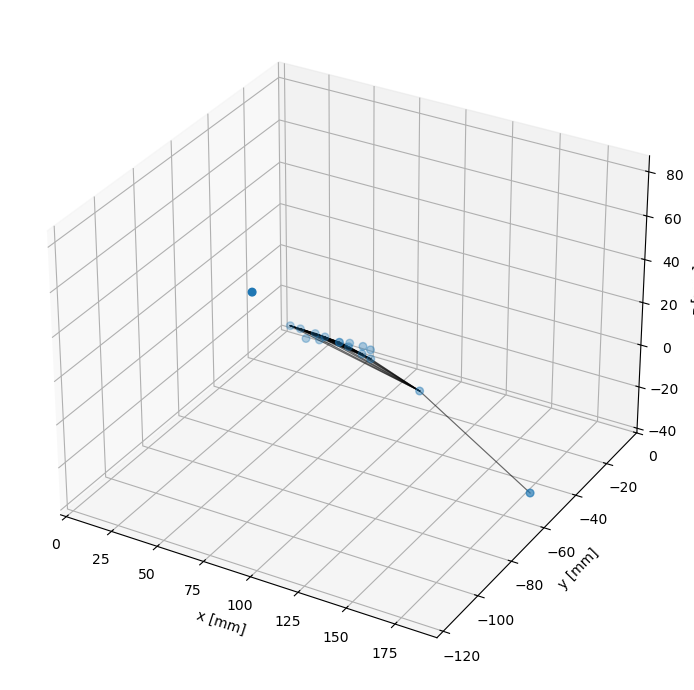

In [4]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset_signal(df_graph, mode = "EC")

# Plot example graph
data = dataset[17]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [5]:
# Split into training, validation, and test sets
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))

# Make DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_45999/1198046484.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_45999/1198046484.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


# Initialize Model and Optimizer

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [7]:
# Initialize model
hidden_size = 40

if use_Edep:
    model = models.MyIN_Edep(hidden_size).to(device)
else:
    model = models.MyIN(hidden_size).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

Total trainable parameters: 18407


In [8]:
# Initialize optimizer

lr = 5E-3
step_size = 5
gamma = 0.9

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

# Train the model

In [9]:
epochs = 300

best_val_loss = math.inf
best_thld = None
best_state_dict = None  # or best_model = None

output = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f"---- Epoch {epoch} ----")
    train_loss = GTT.train(model, device, train_loader, optimizer, epoch)
    val_loss = GTT.validate(model, device, val_loader)

    # keep best model (lowest val loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict()) 

    scheduler.step()

    output['train_loss'].append(train_loss)
    output['val_loss'].append(val_loss)


---- Epoch 1 ----
...epoch time: 65.51796078681946s
...epoch 1: train loss=0.14325783691049104
...val loss= 0.09866269881670636
---- Epoch 2 ----
...epoch time: 68.3581976890564s
...epoch 2: train loss=0.0984907120866763
...val loss= 0.10029599465033175
---- Epoch 3 ----
...epoch time: 69.3456699848175s
...epoch 3: train loss=0.08851723632926775
...val loss= 0.09611846313248795
---- Epoch 4 ----
...epoch time: 69.57382798194885s
...epoch 4: train loss=0.08290882632322433
...val loss= 0.07610667884144437
---- Epoch 5 ----
...epoch time: 69.26420569419861s
...epoch 5: train loss=0.07983380063684156
...val loss= 0.08094695882567209
---- Epoch 6 ----
...epoch time: 70.87890100479126s
...epoch 6: train loss=0.0744676067534618
...val loss= 0.07372707131711816
---- Epoch 7 ----
...epoch time: 69.78377223014832s
...epoch 7: train loss=0.07326823070939527
...val loss= 0.07542337654264708
---- Epoch 8 ----
...epoch time: 70.95960998535156s
...epoch 8: train loss=0.07124531197695719
...val loss= 

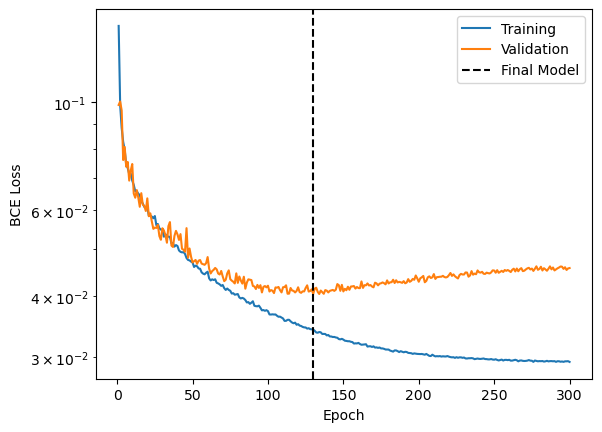

In [10]:
# convert output to pandas DataFrame 
output_df = pd.DataFrame(output)

# Plot the training and validation losses
plt.figure()
plt.plot(np.arange(len(output_df))+1,output_df.train_loss,label='Training')
plt.plot(np.arange(len(output_df))+1,output_df.val_loss,label='Validation')
plt.axvline(x=np.argmin(output_df['val_loss'])+1, linestyle='--', color='k', label='Final Model')

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.yscale('log')
plt.legend()

if use_Edep:
    plt.savefig('/Users/mghrear/data/LDMX_GNN/models/IN_Edep_'+tracker_name+'_signal_training_curve.png')
else:
    plt.savefig('/Users/mghrear/data/LDMX_GNN/models/IN_'+tracker_name+'_signal_training_curve.png')




In [11]:
# Save the best model state dictionary
if use_Edep:
    torch.save(best_state_dict, '/Users/mghrear/data/LDMX_GNN/models/IN_Edep_'+tracker_name+'_signal_state_dict.pt')
else:
    torch.save(best_state_dict, '/Users/mghrear/data/LDMX_GNN/models/IN_'+tracker_name+'_signal_state_dict.pt')
